In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
np.random.seed(123)
tf.random.set_seed(123)

# time series model

In [3]:
df = pd.read_csv(
    r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting\UCI-HAR\UCI HAR Dataset\train\Inertial Signals\body_acc_x_train.txt',
    header = None,
    delim_whitespace = True
)

C:\Users\VARUN\AppData\Local\Temp\ipykernel_788\3254770097.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.000181,0.010139,0.009276,0.005066,0.010810,0.004045,0.004757,0.006214,0.003307,0.007572,...,0.001412,-0.001509,0.000060,0.000435,-0.000819,0.000228,-0.000300,-0.001147,-0.000222,0.001576
1,0.001094,0.004550,0.002879,0.002247,0.003305,0.002416,0.001619,0.000981,0.000009,-0.000363,...,-0.000104,-0.000141,0.001333,0.001541,0.001077,-0.000736,-0.003767,-0.004646,-0.002941,-0.001599
2,0.003531,0.002285,-0.000420,-0.003738,-0.006706,-0.003148,0.000733,0.000668,0.002162,-0.000946,...,0.000661,0.001853,-0.000268,-0.000394,-0.000279,-0.000316,0.000144,0.001246,0.003117,0.002178
3,-0.001772,-0.001311,0.000388,0.000408,-0.000355,0.000998,0.001109,-0.003149,-0.008882,-0.010483,...,0.000458,0.002103,0.001358,0.000820,-0.000212,-0.001915,-0.001631,-0.000867,-0.001172,-0.000028
4,0.000087,-0.000272,0.001022,0.003126,0.002284,0.000885,0.001933,0.002270,0.002247,0.002175,...,0.002529,0.003518,-0.000248,-0.002761,0.000252,0.003752,0.001626,-0.000698,-0.001223,-0.003328


In [5]:
df.shape

(7352, 128)

In [6]:
''' we have N = 7352 samples and each time series has 128 measurements as explained in notes
50 recordings per second and each recording being 2.56 secs long ~2.56*50 = 128 measurements in each time series of 2.56 secs  
'''

' we have N = 7352 samples and each time series has 128 measurements as explained in notes\n50 recordings per second and each recording being 2.56 secs long ~2.56*50 = 128 measurements in each time series of 2.56 secs  \n'

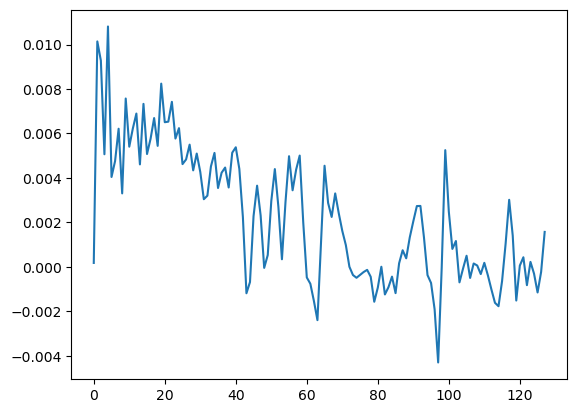

In [7]:
# plotting just 1st row or say one recording out of 7352 recordings of 2.56 seconds containing 128 measurements
df.iloc[0].plot();

In [8]:
T = 128
Ntrain = 7352 # using this since the data shown above is for training data only - test data in separate file
Ntest =  2947 # look at any data file inside G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting\UCI-HAR\UCI HAR Dataset\test\Inertial Signals
D = 9 # 9 files 
K = 6 # num of classes  

In [9]:
def load_data():
    # returns:
    # Xtrain (Ntrain * T * D), Ytrain (Ntrain)
    # Xtest (Ntest * T * D), Ytest (Ntest)
    
    Xtrain = np.zeros((Ntrain, T, D))
    Xtest = np.zeros((Ntest, T, D))

    #train data
    ts_filenames = [
        'body_acc_x_train.txt', 'body_gyro_x_train.txt', 'total_acc_x_train.txt',
        'body_acc_y_train.txt', 'body_gyro_y_train.txt', 'total_acc_y_train.txt',
        'body_acc_z_train.txt', 'body_gyro_z_train.txt', 'total_acc_z_train.txt',
    ]

    ts_file_prefix = 'G:/My Drive/Study/Time Series Analysis Udemy/Data/time series analysis forecasting/UCI-HAR/UCI HAR Dataset/train/'

    for d, fn in enumerate(ts_filenames):
        df = pd.read_csv(
            f'{ts_file_prefix}Inertial Signals/{fn}',
            header = None,
            delim_whitespace = True)
        
        # Ntrain * T array
        x = df.to_numpy()
        Xtrain[:,:,d] = x

    Ytrain = pd.read_csv(f'{ts_file_prefix}/y_train.txt', header = None).to_numpy() - 1 # doing minus 1 since we want it to start from 0 instead of 1
    Ytrain = Ytrain.flatten()

    #test data
    ts_filenames = [
        'body_acc_x_test.txt', 'body_gyro_x_test.txt', 'total_acc_x_test.txt',
        'body_acc_y_test.txt', 'body_gyro_y_test.txt', 'total_acc_y_test.txt',
        'body_acc_z_test.txt', 'body_gyro_z_test.txt', 'total_acc_z_test.txt',
    ]

    ts_file_prefix = 'G:/My Drive/Study/Time Series Analysis Udemy/Data/time series analysis forecasting/UCI-HAR/UCI HAR Dataset/test/'

    for d, fn in enumerate(ts_filenames):
        df = pd.read_csv(
            f'{ts_file_prefix}Inertial Signals/{fn}',
            header = None,
            delim_whitespace = True)
        
        # Ntrain * T array
        x = df.to_numpy()
        Xtest[:,:,d] = x

    Ytest = pd.read_csv(f'{ts_file_prefix}/y_test.txt', header = None).to_numpy() - 1 # doing minus 1 since we want it to start from 0 instead of 1
    Ytest = Ytest.flatten()

    return Xtrain, Ytrain, Xtest, Ytest    
        

In [10]:
Xtrain, Ytrain, Xtest, Ytest = load_data()

C:\Users\VARUN\AppData\Local\Temp\ipykernel_788\1734865465.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_788\1734865465.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_788\1734865465.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_788\1734865465.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_788\1734865465.py:19: FutureWarning: The 'de

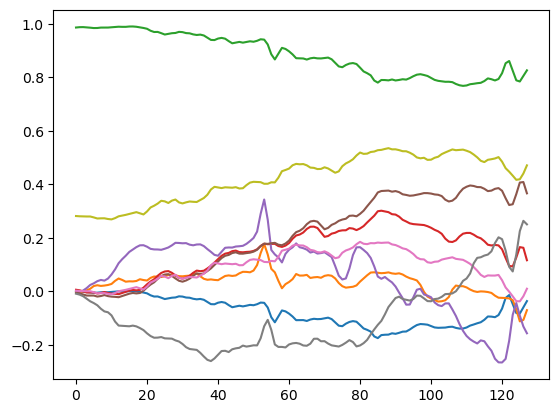

In [11]:
# plot all D time series of length T = 128 for one sample say 7000

# plt.figure(figsize =(15,5))
plt.plot(Xtrain[7000,:,:]);
# plt.show();

In [12]:
# ANN

inputs = []
features = []

# make a neural network for each time series "D"
# this effectively learns the local pattern of each individual time series before looking at the interaction across time series 
# creates summary of shape 16 of individual time series compared to the original 128 size original time series
for d in range(D):
    i = Input(shape = (T,))
    x = Dense (32, activation = 'relu') (i)
    x = Dense (16, activation = 'relu') (x)
    inputs.append(i)
    features.append(x)

# output of concatenate will be D * (size of individual ANN output which is 16)
x = Concatenate()(features)
x = Dense(K) (x)

model = Model(inputs,x)

In [18]:
''' the above is a multitailed neural network - output is considered to be the head of the neural network'''

' the above is a multitailed neural network - output is considered to be the head of the neural network'

In [16]:
tf.keras.utils.plot_model(model)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [14]:
# pip install pydot

In [17]:
checkpoint = ModelCheckpoint('best_model.h5', monitor = 'val_accuracy', save_best_only = True)

In [19]:
model.compile(loss = SparseCategoricalCrossentropy(from_logits = True), optimizer = 'adam', metrics = ['accuracy'])

# if from_logits = False was used the final dense layer in the neural network should have the activation function softmax

In [20]:
Xtrain_split = []
Xtest_split = []
for d in range(D):
    Xtrain_split.append(Xtrain[:,:,d])
    Xtest_split.append(Xtest[:,:,d])

In [25]:
r = model.fit(
    Xtrain_split, # [x1,x2,,,,xd]
    Ytrain,
    epochs =15,
    callbacks = [checkpoint],
    validation_data = (Xtest_split, Ytest)
)
    

Epoch 1/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9781 - loss: 0.0571 - val_accuracy: 0.9216 - val_loss: 0.2457
Epoch 2/15
217/230 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9807 - loss: 0.0522  

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9793 - loss: 0.0533 - val_accuracy: 0.9230 - val_loss: 0.2544
Epoch 3/15
221/230 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9819 - loss: 0.0484  

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9808 - loss: 0.0494 - val_accuracy: 0.9257 - val_loss: 0.2569
Epoch 4/15
227/230 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9826 - loss: 0.0456

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9818 - loss: 0.0467 - val_accuracy: 0.9267 - val_loss: 0.2706
Epoch 5/15
224/230 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9839 - loss: 0.0421    

230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9831 - loss: 0.0430 - val_accuracy: 0.9291 - val_loss: 0.2689
Epoch 6/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9844 - loss: 0.0405 - val_accuracy: 0.9284 - val_loss: 0.2873
Epoch 7/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9856 - loss: 0.0372 - val_accuracy: 0.9247 - val_loss: 0.2946
Epoch 8/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9811 - loss: 0.0481 - val_accuracy: 0.9135 - val_loss: 0.3667
Epoch 9/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9818 - loss: 0.0484 - val_accuracy: 0.9135 - val_loss: 0.3722
Epoch 10/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9871 - loss: 0.0347 - val_accuracy: 0.9199 - val_loss: 0.3294
Epoch 11/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9891 - loss: 0.0300 - val_accuracy: 0.9237 - val_loss: 0.3090
Epoch 12/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9899 - loss: 0.0283 - val_accuracy: 0.9260 - 

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9908 - loss: 0.0254 - val_accuracy: 0.9301 - val_loss: 0.3219
Epoch 15/15
229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9934 - loss: 0.0225

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9922 - loss: 0.0240 - val_accuracy: 0.9311 - val_loss: 0.3265


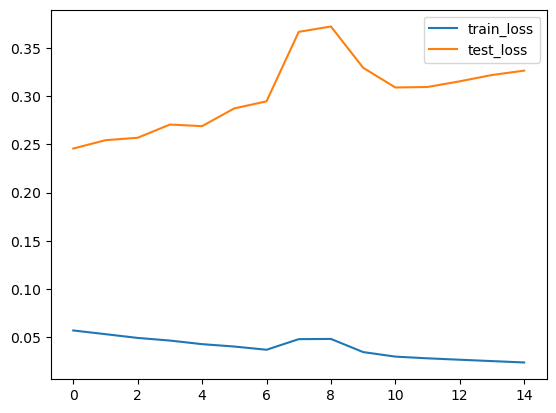

In [26]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'test_loss')
plt.legend();

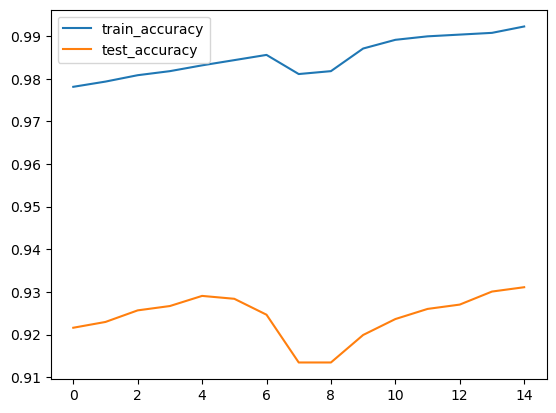

In [27]:
plt.plot(r.history['accuracy'], label = 'train_accuracy')
plt.plot(r.history['val_accuracy'], label = 'test_accuracy')
plt.legend();

In [28]:
# load best model
best_model = tf.keras.models.load_model('best_model.h5')

In [29]:
#make predictions
Ptest = best_model.predict(Xtest_split)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step   


In [31]:
len(Ptest)

2947

In [32]:
Ptest[0]

array([ -7.840274, -10.048441, -19.201077,  -2.976663,   2.156832,
       -31.63893 ], dtype=float32)

In [34]:
Ytest[0]

np.int64(4)

In [35]:
#evaluate
np.mean(np.argmax(Ptest, axis = 1) == Ytest)

np.float64(0.9311163895486936)

In [36]:
'''this seems like a very decent result, but we need a point of comparison or baseline'''

'this seems like a very decent result, but we need a point of comparison or baseline'

# not using time series but the features derived for the time series and converting this into tabular ML model

In [65]:
''' note that we are going to use a file containing pre extracted features which we are not going to compute. this is already done using
the original time series showed in the above section'''

' note that we are going to use a file containing pre extracted features which we are not going to compute. this is already done using\nthe original time series showed in the above section'

In [40]:
from sklearn.preprocessing import StandardScaler

def load_features():
    # returns 
    # X_train (Ntrain X D)
    # X_test (Ntest X D)

    # train data
    df = pd.read_csv(
        r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting\UCI-HAR\UCI HAR Dataset\train\X_train.txt',
        header = None,
        delim_whitespace = True)
    # these features are already precomputed from the original time series explained in the section above

    feat_train = df.to_numpy()

    #test data
    df = pd.read_csv(
        r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting\UCI-HAR\UCI HAR Dataset\test\X_test.txt',
        header = None,
        delim_whitespace = True)

    feat_test = df.to_numpy()

    scaler = StandardScaler()
    feat_train = scaler.fit_transform(feat_train)
    feat_test = scaler.transform(feat_test)

    return feat_train, feat_test
        



In [39]:
feat_train, feat_test = load_features()

C:\Users\VARUN\AppData\Local\Temp\ipykernel_788\636335888.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_788\636335888.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [44]:
feat_train.shape

(7352, 561)

In [46]:
D_feat = feat_train.shape[1]
D_feat #this is the number of columns in the features

561

In [51]:
# Basic ANN
i = Input(shape = (D_feat,))
x = Dense(32, activation ='relu')(i)
x = Dense(K)(x)
model = Model(i,x)

model.compile(loss = SparseCategoricalCrossentropy(from_logits = True), optimizer ='adam', metrics = ['accuracy'])

In [52]:
check_point2 = ModelCheckpoint('best_model_basic.h5', monitor = 'val_accuracy', save_best_only = True)

In [56]:
r = model.fit(
    feat_train,
    Ytrain,
    epochs = 15,
    callbacks = [check_point2],
    validation_data = (feat_test, Ytest),
)

Epoch 1/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9947 - loss: 0.0162 - val_accuracy: 0.9328 - val_loss: 0.2469
Epoch 2/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9954 - loss: 0.0149 - val_accuracy: 0.9345 - val_loss: 0.2494
Epoch 3/15
218/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9959 - loss: 0.0127 

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9954 - loss: 0.0139 - val_accuracy: 0.9379 - val_loss: 0.2480
Epoch 4/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9961 - loss: 0.0128 - val_accuracy: 0.9365 - val_loss: 0.2342
Epoch 5/15
227/230 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9912 - loss: 0.0388  

230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9902 - loss: 0.0390 - val_accuracy: 0.9420 - val_loss: 0.2308
Epoch 6/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9970 - loss: 0.0099 - val_accuracy: 0.9379 - val_loss: 0.2419
Epoch 7/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9963 - loss: 0.0092 - val_accuracy: 0.9420 - val_loss: 0.2256
Epoch 8/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9970 - loss: 0.0080 - val_accuracy: 0.9393 - val_loss: 0.2404
Epoch 9/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9978 - loss: 0.0072 - val_accuracy: 0.9389 - val_loss: 0.2758
Epoch 10/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9986 - loss: 0.0066 - val_accuracy: 0.9321 - val_loss: 0.3222
Epoch 11/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9985 - loss: 0.0058 - val_accuracy: 0.9406 - val_loss: 0.2839
Epoch 12/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9989 - loss: 0.0049 - val_accuracy: 0.9365 - v

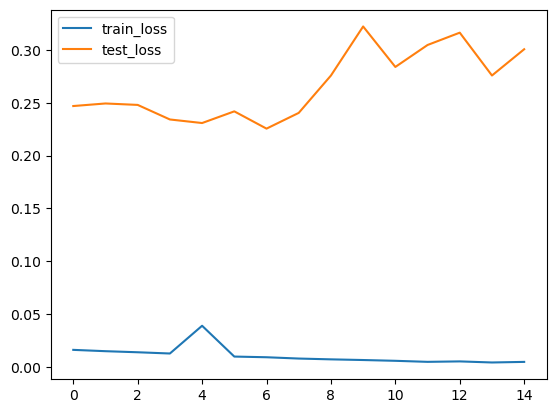

In [57]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'test_loss')
plt.legend();

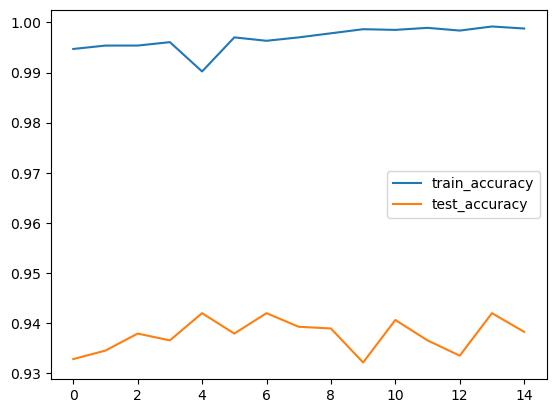

In [58]:
plt.plot(r.history['accuracy'], label = 'train_accuracy')
plt.plot(r.history['val_accuracy'], label = 'test_accuracy')
plt.legend();

In [59]:
''' this model seems to do better than the time series model version'''

' this model seems to do better than the time series model version'

In [60]:
# load best model
best_model = tf.keras.models.load_model('best_model_basic.h5')

In [61]:
# make predictions
Ptest = best_model.predict(feat_test)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [62]:
#evaluate
np.mean(np.argmax(Ptest, axis = 1) == Ytest)

np.float64(0.9419748897183576)

In [64]:
''' using features led to a better performing model compared to using the time series '''

' using features led to a better performing model compared to using the time series '

### trying classic machine learning models and not ANN and using the same features

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [70]:
model = LogisticRegression(solver = 'liblinear') # trains separate bonary models for each class (eg Apple vs Not Apple, orange vs Not orange) etc
model.fit(feat_train, Ytrain)
model.score(feat_train, Ytrain)

0.9945593035908596

In [71]:
''' train accuracy seems pretty high'''

' train accuracy seems pretty high'

In [72]:
model.score(feat_test, Ytest)

0.9613165931455717

In [73]:
''' this is even better than both the neural networks suggesting the decision boundary might be linear'''

' this is even better than both the neural networks suggesting the decision boundary might be linear'

In [74]:
model = SVC()
model.fit(feat_train, Ytrain)
model.score(feat_train, Ytrain)

0.9866702937976061

In [75]:
model.score(feat_test, Ytest)

0.9521547336274178

In [76]:
''' test not as good as logistic regression'''

' test not as good as logistic regression'

In [77]:
# testing the idea that the classification boundaries are linearly separable
model = SVC(kernel ='linear') # using linear kernel for this
model.fit(feat_train, Ytrain)
model.score(feat_train, Ytrain)

0.9968715995647442

In [78]:
model.score(feat_test, Ytest)

0.9609772650152698

In [79]:
''' train and test score both shows an improvement and beats the non linear version'''

' train and test score both shows an improvement and beats the non linear version'

In [80]:
model = RandomForestClassifier()
model.fit(feat_train, Ytrain)
model.score(feat_train, Ytrain)

1.0

In [81]:
model.score(feat_test, Ytest)

0.9321343739395996

In [82]:
''' perfect score on the train set since there is overfitting in the random forest'''

' perfect score on the train set since there is overfitting in the random forest'

# conclusion - feature engineering is very useful and sometimes more practical than using time series and ANN, and use regular machine learning"
### also dont forget to try the linear models as well - they might be a good fit

# Combined model
### multi input time series ANN and feature based ANN?

In [86]:
# combined model

inputs = []
features = [] 

for d in range(D):
    i = Input(shape =(T,))
    x = Dense(32, activation ='relu')(i)
    x = Dense(16, activation ='relu')(x)
    inputs.append(i)
    features.append(x)

i2 =  Input(shape = (D_feat,))
x2 = Dense(32, activation = 'relu') (i2)

x = Concatenate()(features + [x2])
x = Dense(K)(x)

model = Model(inputs + [i2], x)

In [87]:
model.compile(
    loss = SparseCategoricalCrossentropy(from_logits = True),
    optimizer ='adam',
    metrics = ['accuracy'],
)

In [88]:
check_point3 =  ModelCheckpoint('best_model_combined.h5', monitor ='val_accuracy', save_best_only = True)

In [89]:
r = model.fit(
    Xtrain_split + [feat_train],
    Ytrain,
    epochs = 15,
    callbacks =[check_point3],
    validation_data = (Xtest_split + [feat_test], Ytest),
)

Epoch 1/15
229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7885 - loss: 0.5864

230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8970 - loss: 0.2955 - val_accuracy: 0.9291 - val_loss: 0.1917
Epoch 2/15
220/230 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9704 - loss: 0.0894

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9709 - loss: 0.0861 - val_accuracy: 0.9376 - val_loss: 0.1678
Epoch 3/15
226/230 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9773 - loss: 0.0618

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9774 - loss: 0.0620 - val_accuracy: 0.9454 - val_loss: 0.1569
Epoch 4/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9808 - loss: 0.0518 - val_accuracy: 0.9440 - val_loss: 0.1576
Epoch 5/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9841 - loss: 0.0453 - val_accuracy: 0.9440 - val_loss: 0.1604
Epoch 6/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9859 - loss: 0.0409 - val_accuracy: 0.9433 - val_loss: 0.1650
Epoch 7/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9872 - loss: 0.0367 - val_accuracy: 0.9420 - val_loss: 0.1705
Epoch 8/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9891 - loss: 0.0329 - val_accuracy: 0.9416 - val_loss: 0.1736
Epoch 9/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9910 - loss: 0.0297 - val_accuracy: 0.9430 - val_loss: 0.1775
Epoch 10/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9924 - loss: 0.0261 - val_accuracy: 0.9440 - val

230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9933 - loss: 0.0229 - val_accuracy: 0.9484 - val_loss: 0.1710
Epoch 12/15
221/230 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9923 - loss: 0.0220

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9940 - loss: 0.0205 - val_accuracy: 0.9494 - val_loss: 0.1699
Epoch 13/15
217/230 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9921 - loss: 0.0206        

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9942 - loss: 0.0188 - val_accuracy: 0.9552 - val_loss: 0.1547
Epoch 14/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9944 - loss: 0.0173 - val_accuracy: 0.9545 - val_loss: 0.1569
Epoch 15/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9951 - loss: 0.0159 - val_accuracy: 0.9508 - val_loss: 0.1590


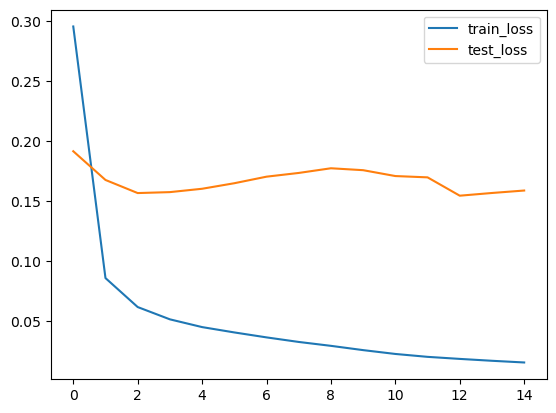

In [90]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'test_loss')
plt.legend();

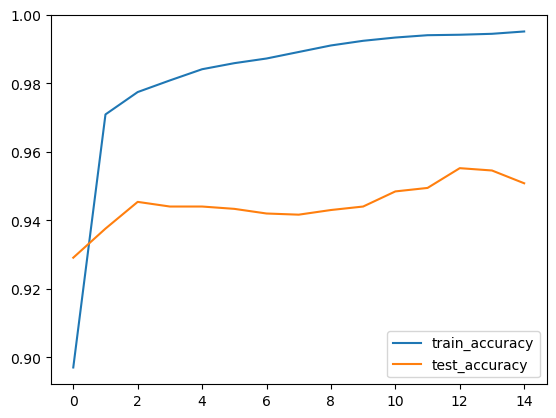

In [91]:
plt.plot(r.history['accuracy'], label = 'train_accuracy')
plt.plot(r.history['val_accuracy'], label = 'test_accuracy')
plt.legend();

In [92]:
''' performing a bit better than what we had before'''

' performing a bit better than what we had before'

In [98]:
best_model = tf.keras.models.load_model('best_model_combined.h5')

In [99]:
Ptest = best_model.predict(Xtest_split + [feat_test])

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step   


In [100]:
np.mean(np.argmax(Ptest, axis =1) == Ytest)

np.float64(0.9552086868001357)

In [101]:
''' this does better than the individual neural network models'''
''' this still doesnt do better than the classic ML models logistic and svc which just learns from the static features'''

' this still doesnt do better than the classic ML models logistic and svc which just learns from the static features'